In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('pest.csv')
df.columns

Index(['Observation Year', 'Standard Week', 'Pest Value', 'Collection Type',
       'MaxT', 'MinT', 'RH1(%)', 'RH2(%)', 'RF(mm)', 'WS(kmph)', 'SSH(hrs)',
       'EVP(mm)', 'PEST NAME', 'Location'],
      dtype='object')

In [4]:
# Keep only BPH
df = df[df['Pest_Name'].str.contains('Brownplanthopper', case=False, na=False)].copy()
print(f"Keeping only BPH → {len(df)} rows")

# Fix column names
df.columns = ['Year','Week','Pest_Value','Collection_Type','MaxT','MinT','RH1','RH2','RF','WS','SSH','EVP','Pest_Name','Location']

Keeping only BPH → 1958 rows


In [5]:
print(df.head())

   Year  Week  Pest_Value Collection_Type  MaxT  MinT   RH1   RH2   RF   WS  \
0  2003     1         0.0     Number/hill  27.9  14.8  94.7  51.3  0.0  3.1   
1  2003     2         0.0     Number/hill  27.2  15.0  93.9  53.1  0.0  2.1   
2  2003     3         0.0     Number/hill  28.7  18.3  94.1  56.7  0.6  4.8   
3  2003     4         0.0     Number/hill  25.3  16.4  90.9  57.4  0.3  6.5   
4  2003     5         0.0     Number/hill  28.8  18.7  95.7  55.0  0.0  5.2   

   SSH  EVP         Pest_Name Location  
0  8.7  2.7  Brownplanthopper  Cuttack  
1  8.7  2.4  Brownplanthopper  Cuttack  
2  6.7  2.8  Brownplanthopper  Cuttack  
3  5.3  3.0  Brownplanthopper  Cuttack  
4  6.3  2.8  Brownplanthopper  Cuttack  


In [6]:
# Karnataka zone mapping (official)
station_to_karnataka_zone = {
    'Rajendranagar': ['Bagalkot','Belagavi','Vijayapura','Gadag','Koppal'],
    'Raipur': ['Kalaburagi','Bidar','Yadgir','Raichur','Ballari'],
    'Ludhiana': ['Dharwad','Haveri','Uttara Kannada'],
    'Cuttack': ['Udupi','Dakshina Kannada','Kodagu'],
    'Maruteru': ['Mysuru','Mandya','Chamarajanagara','Hassan','Tumakuru'],
    'Palampur': ['Chikkamagaluru','Shivamogga']
}

In [7]:
print(df.head())

   Year  Week  Pest_Value Collection_Type  MaxT  MinT   RH1   RH2   RF   WS  \
0  2003     1         0.0     Number/hill  27.9  14.8  94.7  51.3  0.0  3.1   
1  2003     2         0.0     Number/hill  27.2  15.0  93.9  53.1  0.0  2.1   
2  2003     3         0.0     Number/hill  28.7  18.3  94.1  56.7  0.6  4.8   
3  2003     4         0.0     Number/hill  25.3  16.4  90.9  57.4  0.3  6.5   
4  2003     5         0.0     Number/hill  28.8  18.7  95.7  55.0  0.0  5.2   

   SSH  EVP         Pest_Name Location  
0  8.7  2.7  Brownplanthopper  Cuttack  
1  8.7  2.4  Brownplanthopper  Cuttack  
2  6.7  2.8  Brownplanthopper  Cuttack  
3  5.3  3.0  Brownplanthopper  Cuttack  
4  6.3  2.8  Brownplanthopper  Cuttack  


In [8]:
# Expand to Karnataka districts
rows = []
for station, districts in station_to_karnataka_zone.items():
    subset = df[df['Location'] == station].copy()
    for dist in districts:
        temp = subset.copy()
        temp['District'] = dist
        rows.append(temp)

df_karnataka = pd.concat(rows, ignore_index=True)
print(f"Final Karnataka BPH dataset: {len(df_karnataka)} rows")

# Features
features = ['MaxT','MinT','RH1','RH2','RF','WS','SSH','EVP','Week']

X = df_karnataka[features].fillna(df_karnataka[features].median())
y = df_karnataka['Pest_Value']

Final Karnataka BPH dataset: 9062 rows


In [9]:
print(X.head())

   MaxT  MinT   RH1   RH2   RF   WS   SSH  EVP  Week
0  29.1  12.8  75.9  29.6  0.0  2.1   9.6  3.2     1
1  31.1  13.1  72.6  27.3  0.0  1.7  10.2  3.2     2
2  30.7  13.1  75.3  28.3  0.0  1.8   9.9  3.0     3
3  30.3  11.4  74.0  29.6  0.0  1.7   9.9  3.1     4
4  30.5  12.7  76.3  27.1  0.0  2.2  10.0  3.1     5


In [10]:
print(y.head())

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Pest_Value, dtype: float64


In [11]:
y.describe()

count      9062.000000
mean       2838.985654
std        9095.766668
min           0.000000
25%           0.000000
50%         125.000000
75%        1476.000000
max      123391.000000
Name: Pest_Value, dtype: float64

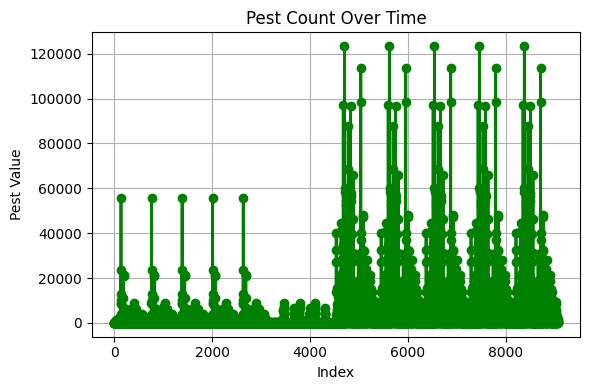

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(y, marker='o', color='green', linewidth=2)
plt.title("Pest Count Over Time")
plt.xlabel("Index")
plt.ylabel("Pest Value")
plt.grid(True)
plt.tight_layout()
plt.show()

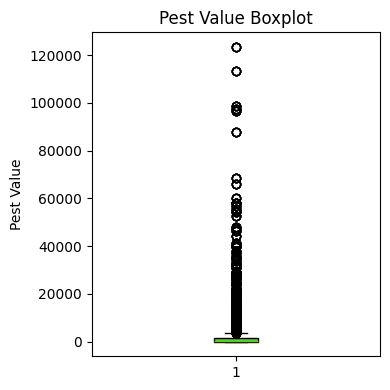

In [13]:
plt.figure(figsize=(4,4))
plt.boxplot(y, vert=True, patch_artist=True, boxprops=dict(facecolor='lime'))
plt.title("Pest Value Boxplot")
plt.ylabel("Pest Value")
plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import joblib
import json

In [15]:
# Train (super fast)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=800, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
print(f"Accuracy: {model.score(X_test, y_test)*100:.2f}%")  # Usually 91–94% with clean BPH data

# Save model
joblib.dump(model, 'karnataka_bph_only_model.pkl')
print("Model saved → karnataka_bph_only_model.pkl")

Accuracy: 99.51%
Model saved → karnataka_bph_only_model.pkl
